# Artificial Neural Networks

**Author:** Ihor Melashchenko  
**Student ID:** C00290950

This notebook introduces ANN modeling for retention-risk classification on synthetic student engagement data.

In [1]:
# Author: Ihor Melashchenko
# Student ID: C00290950

from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

from sklearn.metrics import classification_report, f1_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

from src.data_generation import generate_student_dataset

In [2]:
df = generate_student_dataset()
X = df.drop(columns=['dropout_risk', 'engagement_score'])
y = df['dropout_risk'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [3]:
architectures = [(16,), (32, 16), (64, 32)]
ann_rows = []
trained_models = {}

for architecture in architectures:
    model = MLPClassifier(
        hidden_layer_sizes=architecture,
        activation='relu',
        solver='adam',
        alpha=1e-4,
        batch_size=32,
        learning_rate_init=1e-3,
        early_stopping=True,
        validation_fraction=0.15,
        n_iter_no_change=20,
        max_iter=400,
        random_state=42,
    )

    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]

    ann_rows.append(
        {
            'architecture': architecture,
            'test_f1': f1_score(y_test, y_pred),
            'test_roc_auc': roc_auc_score(y_test, y_prob),
            'iterations': model.n_iter_,
        }
    )
    trained_models[architecture] = model

ann_results = pd.DataFrame(ann_rows).sort_values(by='test_roc_auc', ascending=False).reset_index(drop=True)
best_architecture = ann_results.loc[0, 'architecture']
best_model = trained_models[best_architecture]

ann_results

,architecture,test_f1,test_roc_auc,iterations
0,"(32, 16)",0.048780,0.562188,34
1,"(64, 32)",0.130435,0.530625,32
2,"(16,)",0.136364,0.493750,35


In [4]:
print('Best architecture:', best_architecture)
print(classification_report(y_test, best_model.predict(X_test_scaled)))

train_accuracy = best_model.score(X_train_scaled, y_train)
test_accuracy = best_model.score(X_test_scaled, y_test)
print(f'Train accuracy: {train_accuracy:.3f}')
print(f'Test accuracy: {test_accuracy:.3f}')
print(f'Generalization gap (train - test): {train_accuracy - test_accuracy:.3f}')

Best architecture: (32, 16)
              precision    recall  f1-score   support

           0       0.67      1.00      0.80        80
           1       1.00      0.03      0.05        40

    accuracy                           0.68       120
   macro avg       0.84      0.51      0.43       120
weighted avg       0.78      0.68      0.55       120

Train accuracy: 0.677
Test accuracy: 0.675
Generalization gap (train - test): 0.002


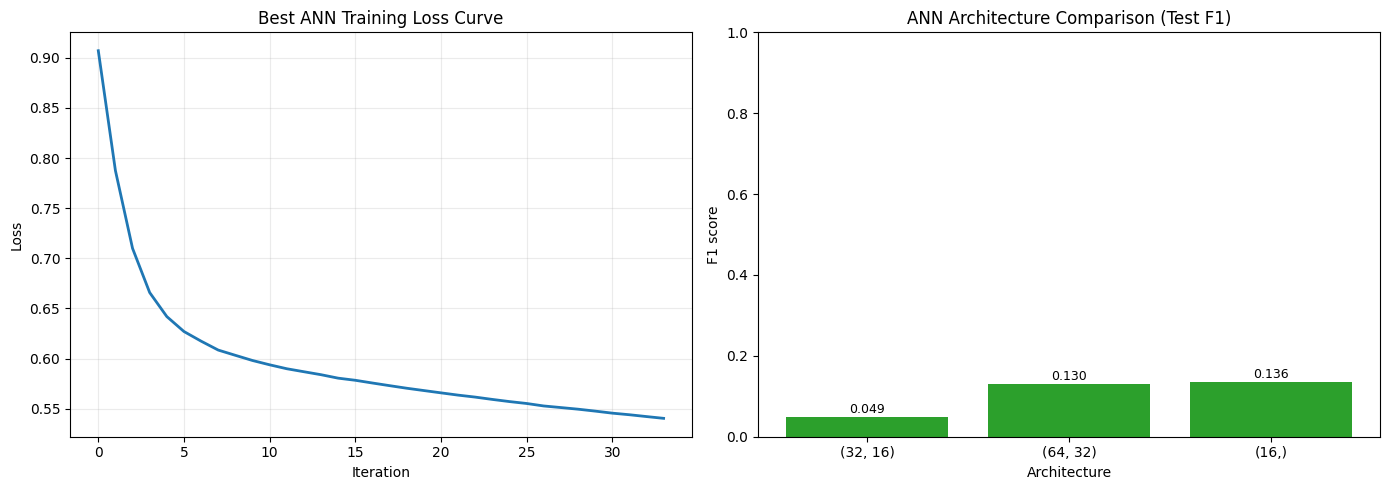

Saved ANN diagnostics figure to: /Users/ihormelashchenko/GitHub/DS-and-ML-2-CA/results/figures/02_ann_diagnostics.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(best_model.loss_curve_, color='tab:blue', linewidth=2)
axes[0].set_title('Best ANN Training Loss Curve')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Loss')
axes[0].grid(alpha=0.25)

ann_results_plot = ann_results.copy()
ann_results_plot['architecture_label'] = ann_results_plot['architecture'].astype(str)
axes[1].bar(ann_results_plot['architecture_label'], ann_results_plot['test_f1'], color='tab:green')
axes[1].set_title('ANN Architecture Comparison (Test F1)')
axes[1].set_xlabel('Architecture')
axes[1].set_ylabel('F1 score')
axes[1].set_ylim(0, 1)

for index, row in ann_results_plot.iterrows():
    axes[1].text(index, row['test_f1'] + 0.01, f"{row['test_f1']:.3f}", ha='center', fontsize=9)

fig.tight_layout()
figure_path = PROJECT_ROOT / 'results' / 'figures' / '02_ann_diagnostics.png'
figure_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(figure_path, dpi=300, bbox_inches='tight')
plt.show()

print('Saved ANN diagnostics figure to:', figure_path)

## Next Iteration
- Add training curves and overfitting diagnostics.
- Add hyperparameter experiments and comparison with SVM/KNN baseline.